In [113]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import (
    TrueRejection,
    FalseRejection,
    Rejection,
    RelativeFrobeniusNorm,
    ComputeAll,
    RobustRelativeProcrustesDistance,
)

from src.helper_functions._metrics_helper import rv_coefficient, rv_coefficient_adjusted, observed_cvm_dependency

from src.methods import (
    PermutationTest,
    RVPermutationTest,
    FitIndependent,
    LLKRatioTest,
    DiffusionCorrelation,
    CanonicalCorrelationTest,
    QAP,
    ObservedCVM
)
from src.solvers.binary_network import MLE_logistic
from src.solvers.MaMa_uuuuu import pgd_fit_wrapper, pgd_fit
from src.solvers.weighted_network import MLE_gaussian, ASE
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
from src.helper_functions.plot_functions import plot_grid, plot_with_bands, plot_scatter_markers
import scipy.stats as stats
from src.helper_functions.plot_functions import visualise_latent, plot_heatmap
from functools import partial
import seaborn as sns

<Axes: >

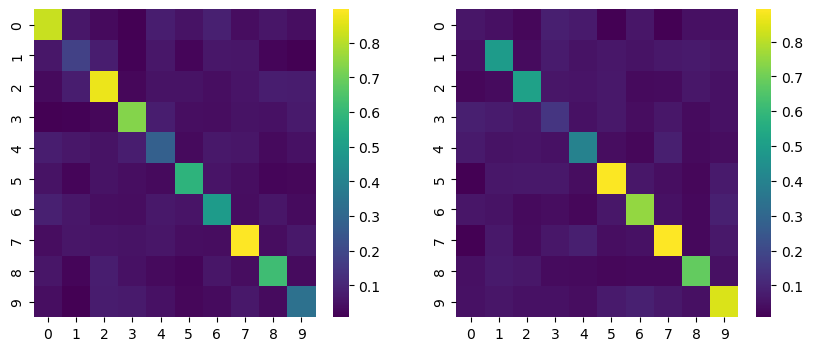

In [126]:
community_assignment = np.zeros((100, 2))
community_assignment[:70, 0] = 1
community_assignment[70:, 1] = 1
community_assignment = [community_assignment for _ in range(2)]

block_probs = np.array([[0.8, 0.2], [0.2, 0.8]])
block_probs = [block_probs for _ in range(2)]

m = BernoulliNetwork(n=200, k=10, sbm=True, 
                     assignment_mode='correlated', 
                     block_probs_type='random',
                     num_networks=2, 
                     assortativity=0.9, 
                     prob_switch=0.2,
                     sparsity_bias=0.5)
data = m.generate()
A = data['A']
B = data['B']
X = data['X']
Z = data['Z']

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(m.block_probs[0], cmap='viridis', ax=ax[0])
sns.heatmap(m.block_probs[1], cmap='viridis', ax=ax[1])

<Axes: >

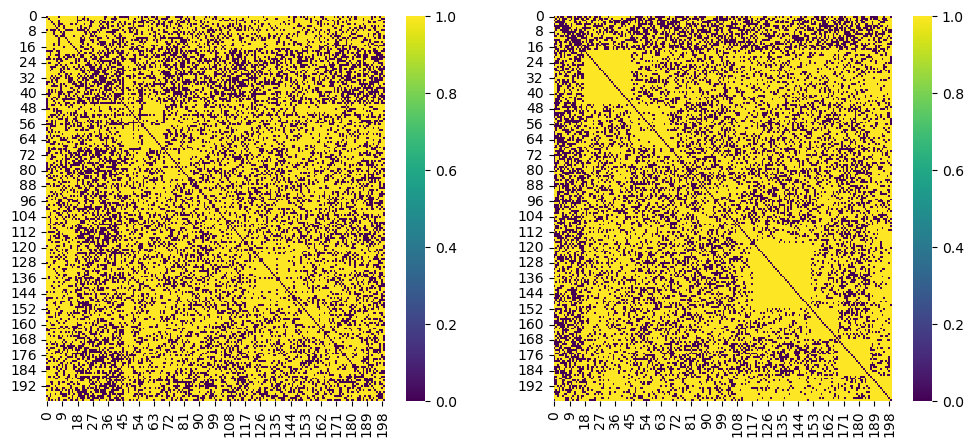

In [127]:
ordering = np.argsort(np.argmax(m.community_assignment[1], axis=1))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(A[ordering][:, ordering], cmap='viridis', ax=ax[0])
sns.heatmap(B[ordering][:, ordering], cmap='viridis', ax=ax[1])

In [45]:
method = QAP(rho=0, p_val_type='traditional', npermutations=100)
method2 = QAP(rho=0, p_val_type='new', npermutations=100)

method.fit(data)
method2.fit(data)
method.get_estimated(), method2.get_estimated()

({'estimated_latent': None,
  'true_latent': None,
  'p-value': np.float64(0.9),
  'reject_null': False,
  'null': True},
 {'estimated_latent': None,
  'true_latent': None,
  'p-value': np.float64(0.82),
  'reject_null': False,
  'null': True})

In [5]:
out = []
out2 = []
for _ in range(100):
    m = BernoulliNetwork(n=200, k=3, sbm=True, 
                     assignment_mode='random', 
                     block_probs_type='random',
                     num_networks=2, 
                     assortativity=0.5, 
                     prob_switch=0.1,
                     sparsity_bias=0.7)
    data = m.generate()
    A = data['A']
    B = data['B']
    X = data['X']
    Z = data['Z']
    out.append(A.sum()/A.size)
    out2.append(observed_cvm_dependency(A, B))

print(sum(out) / len(out))
print(sum(out2) / len(out2))

for _ in range(100):
    m1 = BernoulliNetwork(n=200, k=3, sbm=True, 
                     assignment_mode='correlated', 
                     block_probs_type='switched',
                     rng=np.random.default_rng(),
                     num_networks=2, 
                     assortativity=0.5, 
                     prob_switch=0.5,
                     sparsity_bias=0.7)
    
    data = m1.generate()
    A = data['A']
    B = data['B']
    X = data['X']
    Z = data['Z']
    out.append(A.sum()/A.size)
    out2.append(observed_cvm_dependency(A, B))

print(sum(out) / len(out))
print(sum(out2) / len(out2))

0.42226050000000015
1.3098251126562885
0.4238235000000002
2.3996479783504303


np.float64(0.10777631655469465)

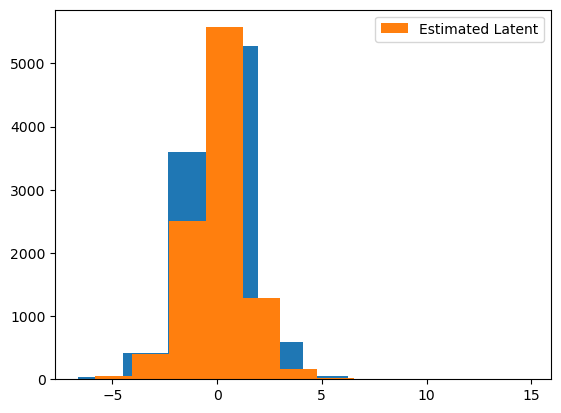

In [5]:
column_covariance = np.array([[1, 0], [0, 1]])

m = GaussianNetwork(n=100, k=2, rho=1, marginals='gaussian', copula='gaussian', center_latent=True, column_covariance=column_covariance)
data = m.generate()

plt.hist((data['Z']@data['Z'].T).flatten())
out = ASE(data['A'], k=2)
plt.hist((out[0]@out[0].T).flatten(), label='Estimated Latent')
plt.legend()
RelativeFrobeniusNorm(gram_matrix=True)({'estimated_latent':out[0], 'true_latent':data['Z']})

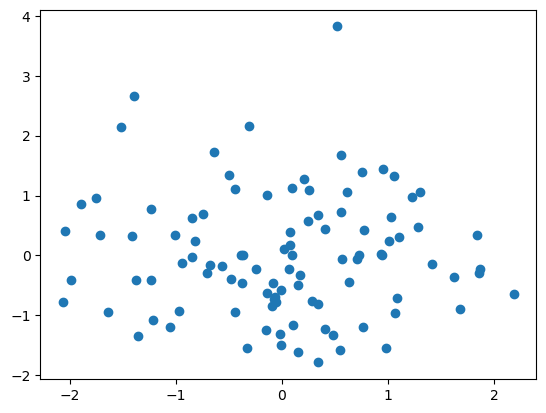

In [6]:
plt.scatter(data['Z'][:, 0], data['Z'][:, 1], label='True Latent')

In [7]:
data['X'].T@data['X']

array([[ 93.24435727,  -3.37804962],
       [ -3.37804962, 101.71973204]])

In [8]:
# out = []
# density = []
# marginal = ['uniform -2 -1', 'uniform -1 1', 'uniform 0 1', 'uniform 0 2', 'uniform 1 2']
# for i in range(50):
#     m = BernoulliNetwork(n=100, k=3, rho=0, marginals=marginal[i % 5], center_latent=False, self_loops=False)
#     data = m.generate()
#     density.append(data['A'].sum()/data['A'].size)

#     out.append(observed_cvm_dependency(data['A'], data['B']))

# print(np.mean(out))
# plt.scatter(density, out)

In [9]:
# nsim = 5
# n = [100]
# k = [1]
# rho = [0.2]
# alpha = [0.05]
# marginals = ['gaussian']
# edge_var = [1]

# method = [
#     partial(RVPermutationTest, permutation_type="latent"),
#     # partial(RVPermutationTest, permutation_type="observed"),
#     # LLKRatioTest,
#     QAP,
#     DiffusionCorrelation,
#     # partial(CanonicalCorrelationTest, permutation_type="latent"),
#     partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=2)),
#     # partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=1)),
#     # partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=3)),
#     # FitIndependent
# ]

# npermutations = [200]
# metrics = [ComputeAll()]
# approximation = ["F-distr"]


# model = partial(BernoulliNetwork, center_latent=True, self_loops=False)

# setup = [
#     # (partial(GaussianNetwork, latent_sim='linear', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='exponential', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='cubic', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='quadratic', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='w_shaped', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='spiral', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='step', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='fourth_root', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='joint_normal', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='logarithmic', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='sin_sixteen_pi', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='square', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='diamond', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='circle', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='ellipse', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='two_parabolas', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(GaussianNetwork, latent_sim='uncorrelated_bernoulli', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     #(partial(GaussianNetwork, latent_sim='multiplicative_noise', sim_kwargs={'noise':True}), partial(ASE, k=2)),

#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='linear', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='exponential', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='cubic', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='quadratic', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='w_shaped', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='spiral', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='step', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='fourth_root', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='joint_normal', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='logarithmic', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='sin_sixteen_pi', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='square', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='diamond', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='circle', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='ellipse', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='two_parabolas', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='uncorrelated_bernoulli', sim_kwargs={'noise':True}), partial(ASE, k=k[0])),
#     # (partial(BernoulliNetwork, rdpg='minmax', latent_sim='multiplicative_noise', sim_kwargs={'noise':True}), partial(ASE, k=2)),

# ]

# rng = np.random.default_rng(0)    

# param_names = [
#     "setup",
#     "method",
#     "n",
#     "k",
#     "rho",
#     "alpha",
#     "marginals",
#     "edge_var",
#     "approximation",
#     "npermutations",
# ]

# param_values = product(
#     setup, method, n, k, rho, alpha, marginals, edge_var, approximation, npermutations
# )

# factorial_design = [dict(zip(param_names, v)) for v in param_values]

# out = run_simulation(
#     nsim=nsim,
#     metrics=metrics,
#     factorial_design=factorial_design,
#     rng=rng,
#     parallel=True,
# )

# out = pd.DataFrame(out)

In [8]:
nsim = 5
n = [150]
k = [3]
rho = [0.5]
alpha = [0.05]
marginals = ['gaussian']
assortativity = [0.5]
sparsity_bias = [0.6]
prob_switch = [0.5]
assignment_mode = ['random', 'correlated']
block_probs_type = ['random', 'identical']

edge_var = [1]
method = [
    partial(RVPermutationTest, permutation_type="latent"),
    QAP,
    DiffusionCorrelation,
    partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=2)),
]

npermutations = [100]
metrics = [ComputeAll()]

sbm = [True]

setup = [ 
    (partial(GaussianNetwork, sbm=True), ASE),
    (partial(GaussianNetwork, sbm=True), ASE),
    (partial(BernoulliNetwork, sbm=True), ASE),
    (partial(BernoulliNetwork, sbm=True), ASE),
]

rng = np.random.default_rng(2)    

param_names = [
    "setup",
    "method",
    "n",
    "k",
    "alpha",
    "marginals",
    "edge_var",
    "npermutations",
    "rho",
    "assortativity",
    "sparsity_bias",
    "prob_switch",
    "assignment_mode",
    "block_probs_type",
]

param_values = product(
    setup, method, n, k, alpha, marginals, edge_var, npermutations, rho, assortativity, sparsity_bias, prob_switch, assignment_mode, block_probs_type
)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(
    nsim=nsim,
    metrics=metrics,
    factorial_design=factorial_design,
    rng=rng,
    parallel=True,
)

Running scenarios: 100%|██████████| 320/320 [05:04<00:00,  1.05it/s]


In [14]:
# nsim = 5
# n = [150]
# k = [3]
# rho = [0.2]
# alpha = [0.05]
# marginals = ['gaussian']
# edge_var = [1]
# method = [
#     # partial(RVPermutationTest, permutation_type="latent"),
#     QAP,
#     DiffusionCorrelation,
#     partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=2)),
#     # partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=1)),
# ]

# npermutations = [100]
# df = [3]
# metrics = [ComputeAll()]

# column_covariance = [
#     np.array(
#         [[1, 0.9, 0.0], 
#          [0.9, 1, 0.0],
#          [0.0, 0.0, 1]]
#         ), 
    
#     np.array([[3, 0, 0], [0, 1, 0], [0, 0, 0.5]])]

# approximation = ["F-distr"]

# setup = [ 
#     (partial(GaussianNetwork, copula_model='gaussian'), ASE),
    
    
#     # (partial(GaussianNetwork, copula_model='clayton'), ASE),
#     # (partial(GaussianNetwork, copula_model='gumbel'), ASE),
#     (partial(GaussianNetwork, copula_model='student_t', df=3), ASE),
#     (partial(GaussianNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.5, -0.5]), ASE),
    
#     (partial(BernoulliNetwork, copula_model='gaussian'), pgd_fit_wrapper),
#     # (partial(BernoulliNetwork, copula_model='clayton'), pgd_fit_wrapper),
#     # (partial(BernoulliNetwork, copula_model='gumbel'), pgd_fit_wrapper),
#     (partial(BernoulliNetwork, copula_model='student_t', df=3), pgd_fit_wrapper),
#     (partial(BernoulliNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.5, -0.5]), pgd_fit_wrapper),
# ]

# rng = np.random.default_rng(2)    

# param_names = [
#     "setup",
#     "method",
#     "n",
#     "k",
#     "alpha",
#     "marginals",
#     "rho",
#     "df",
#     "edge_var",
#     "approximation",
#     "npermutations",
#     "column_covariance"
# ]

# param_values = product(
#     setup, method, n, k, alpha, marginals, rho, df, edge_var, approximation, npermutations, column_covariance
# )

# factorial_design = [dict(zip(param_names, v)) for v in param_values]

# out = run_simulation(
#     nsim=nsim,
#     metrics=metrics,
#     factorial_design=factorial_design,
#     rng=rng,
#     parallel=True,
# )

In [9]:
out = pd.DataFrame(out)

In [10]:
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x.get("edge_var", "NA"))
out["approximation"] = out["args"].apply(lambda x: x.get("approximation", "NA"))
out["dgp"] = out["args"].apply(lambda x: x["setup"][0].func.__name__)
out["solver"] = out["args"].apply(lambda x: x["setup"][1].__name__)
out['rho'] = out["args"].apply(lambda x: x.get("rho", "NA"))
out["method"] = out["args"].apply(lambda x: x.get("method_name", "NA"))
out["marginals"] = out["args"].apply(lambda x: x.get("marginals", "NA"))
out["copula"] = out["args"].apply(lambda x: x["setup"][0].keywords.get("copula_model", "NA"))
out['sparsity_bias'] = out["args"].apply(lambda x: x.get("sparsity_bias", "NA"))
out['assignment_mode'] = out["args"].apply(lambda x: x.get("assignment_mode", "NA"))
out['block_probs_type'] = out["args"].apply(lambda x: x.get("block_probs_type", "NA"))

out['column_covariance'] = out['args'].apply(lambda x: x.get("column_covariance", "NA"))

In [11]:
def label_covariance(arr):
    if np.array_equal(arr, [[1, 0.9, 0], [0.9, 1, 0], [0, 0, 1]]):
        return 'correlated'
    if np.array_equal(arr, [[3, 0, 0], [0, 1, 0], [0, 0, 0.5]]):
        return 'diff_variance'
    return arr

out['column_covariance'] = out['column_covariance'].apply(label_covariance)

In [12]:
temp = out[out['method'] == 'ObservedCVMPermutationTest'].copy()
temp['method'] = temp['method'] + '_' + temp['args'].apply(lambda x: str(x['method'].keywords['test_function'].keywords['degree']))
out.loc[out['method'] == 'ObservedCVMPermutationTest', 'method'] = temp['method']

In [13]:
out["latent_sim"] = out["args"].apply(
    lambda x: x["setup"][0].keywords.get("latent_sim", "NA")
)

In [14]:
out["marginals_sim"] = out['marginals'] + out['latent_sim']

In [15]:
out["FalseRejection"] = out["ComputeAll"].apply(lambda x: x["FalseRejection"])
out["TrueRejection"] = out["ComputeAll"].apply(lambda x: x["TrueRejection"])
out["Rejection"] = out["ComputeAll"].apply(lambda x: x["Rejection"])
out['RelativeFrobeniusNorm_x'] = out["ComputeAll"].apply(lambda x: x.get("RelativeFrobeniusNorm_x", np.nan))
out['ProcrustesDistance_x'] = out["ComputeAll"].apply(lambda x: x.get("ProcrustesDistance_x", np.nan))
out['RelativeFrobeniusNorm_z'] = out["ComputeAll"].apply(lambda x: x.get("RelativeFrobeniusNorm_z", np.nan))
out['ProcrustesDistance_z'] = out["ComputeAll"].apply(lambda x: x.get("ProcrustesDistance_z", np.nan))

In [16]:
out['density_A'] = out['density'].apply(lambda x: x[0])
out['density_B'] = out['density'].apply(lambda x: x[1])

In [17]:
results_gaussian = out[out["dgp"] == "GaussianNetwork"]
results_bernoulli = out[out["dgp"] == "BernoulliNetwork"]

results_null_gaussian = results_gaussian[(results_gaussian["assignment_mode"] == 'random') & (results_gaussian["block_probs_type"] == 'random')]
results_null_bernoulli = results_bernoulli[(results_bernoulli["assignment_mode"] == 'random') & (results_bernoulli["block_probs_type"] == 'random')]

results_alt_gaussian = results_gaussian[~((results_gaussian["assignment_mode"] == 'random') & (results_gaussian["block_probs_type"] == 'random'))]
results_alt_bernoulli = results_bernoulli[~((results_bernoulli["assignment_mode"] == 'random') & (results_bernoulli["block_probs_type"] == 'random'))]

results_null_gaussian_correlated = results_null_gaussian[
    results_null_gaussian["column_covariance"] == "correlated"
]

results_null_gaussian_diff_variance = results_null_gaussian[
    results_null_gaussian["column_covariance"] == "diff_variance"
]

results_null_gaussian_rv = results_null_gaussian[
    results_null_gaussian["method"] == "RVPermutationTest"
]
results_null_gaussian_llk = results_null_gaussian[
    results_null_gaussian["method"] == "LLKRatioTest"
]

results_05_gaussian = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.5)
]

results_05_bernoulli = out[
    (out['dgp'] == "BernoulliNetwork") & (out['rho'] == 0.5)
]

results_02_bernoulli = out[
    (out['dgp'] == "BernoulliNetwork") & (out['rho'] == 0.2)
]

results_02_gaussian = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.2)
]

results_02_gaussian_correlated = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.2) & (out['column_covariance'] == 'correlated')
]

results_02_gaussian_diff_variance = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.2) & (out['column_covariance'] == 'diff_variance')
]

In [24]:
# agg_gaussian_x = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )

# agg_gaussian_x = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )
# agg_gaussian_z = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_x = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_z = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )

# agg_gaussian_null = aggregate_results(
#     results_null_gaussian,
#     y_axis="TrueRejection",
#     x_axis="n",
#     factors=["marginals_sim", "latent_sim", "method"],
# )

# agg_05_gaussian = aggregate_results(
#     results_05_gaussian,
#     y_axis="TrueRejection",
#     x_axis="n",
#     factors=["marginals_sim", "latent_sim", "method"],
# )

# agg_bernoulli_null = aggregate_results(
#     results_null_bernoulli,
#     y_axis="TrueRejection",
#     x_axis="n",
#     factors=["marginals_sim", "latent_sim", "method"],
# )

# agg_05_bernoulli = aggregate_results(
#     results_05_bernoulli,
#     y_axis="TrueRejection",
#     x_axis="n",
#     factors=["marginals_sim", "latent_sim", "method"],
# )

agg_02_bernoulli = aggregate_results(
    results_02_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["copula", "marginals", "method", "column_covariance"],
)
agg_02_gaussian = aggregate_results(
    results_02_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["copula", "marginals", "method", "column_covariance"],
)

agg_02_gaussian_correlated = aggregate_results(
    results_02_gaussian_correlated,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["copula", "marginals", "method"],
)
agg_02_gaussian_diff_variance = aggregate_results(
    results_02_gaussian_diff_variance,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["copula", "marginals", "method"],
)

agg_null_gaussian = aggregate_results(
    results_null_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["method"],
)

agg_null_bernoulli = aggregate_results(
    results_null_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["method"],
)

agg_alt_gaussian = aggregate_results(
    results_alt_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["method", "assignment_mode", "block_probs_type"],
)
agg_alt_bernoulli = aggregate_results(
    results_alt_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["method", "assignment_mode", "block_probs_type"],
)

In [25]:
agg_alt_gaussian

,n,method,assignment_mode,block_probs_type,Rejection_mean,Rejection_sem
0,150,DiffusionCorrelation,correlated,identical,0.0,0.000000
1,150,DiffusionCorrelation,correlated,random,0.2,0.133333
2,150,DiffusionCorrelation,random,identical,0.0,0.000000
3,150,ObservedCVMPermutationTest_2,correlated,identical,0.4,0.163299
4,150,ObservedCVMPermutationTest_2,correlated,random,0.1,0.100000
5,150,ObservedCVMPermutationTest_2,random,identical,0.1,0.100000
6,150,QAP,correlated,identical,0.0,0.000000
7,150,QAP,correlated,random,0.1,0.100000
8,150,QAP,random,identical,0.1,0.100000
9,150,RVPermutationTest_latent,correlated,identical,0.4,0.163299


/var/folders/gg/0gs3g0gx6w57ybpx_mss5wdh0000gq/T/ipykernel_54055/758325023.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp['method'].replace({


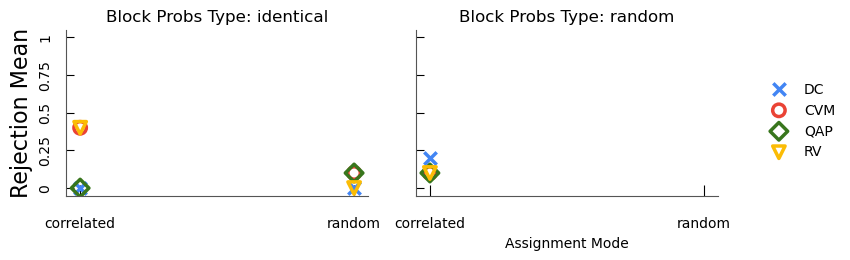

In [26]:
temp = agg_alt_gaussian.copy()
temp = temp[temp['n']==150]
temp['method'].replace({
    'DiffusionCorrelation':'DC', 
    'ObservedCVMPermutationTest_2':'CVM', 
    'QAP':'QAP', 
    'RVPermutationTest_latent':'RV'
}, inplace=True)
#temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

colors = {
    'DC': '#4285F4', # Blue
    'CVM': '#EA4335', # Red
    'QAP': '#38761D',  # Dark Green
    'RV': '#FBBC05'  # Yellow
}

marker_map = {
    'DC': 'x',
    'CVM': 'o',
    'QAP': 'D',
    'RV': 'v'
}

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="assignment_mode",
    y_axis="Rejection_mean",
    factors=["method", 'block_probs_type'],
    height=2.5,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    show_row_names=False,
    title="",
)

/var/folders/gg/0gs3g0gx6w57ybpx_mss5wdh0000gq/T/ipykernel_74888/3825549348.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp['method'].replace({


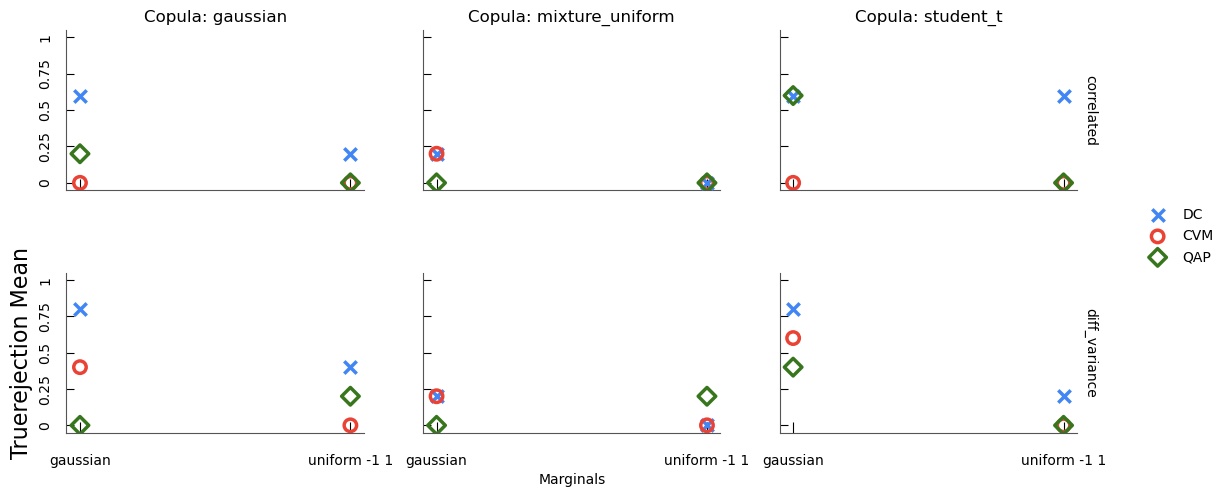

In [ ]:
temp = agg_02_bernoulli.copy()
temp = temp[temp['n']==150]
temp['method'].replace({
    'DiffusionCorrelation':'DC', 
    'ObservedCVMPermutationTest_2':'CVM', 
    'QAP':'QAP', 
    'RVPermutationTest_latent':'RV'
}, inplace=True)
#temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

colors = {
    'DC': '#4285F4', # Blue
    'CVM': '#EA4335', # Red
    'QAP': '#38761D',  # Dark Green
    'RV': '#FBBC05'  # Yellow
}

marker_map = {
    'DC': 'x',
    'CVM': 'o',
    'QAP': 'D',
    'RV': 'v'
}

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="TrueRejection_mean",
    factors=["method", 'copula', "column_covariance"],
    height=2.5,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    show_row_names=False,
    title="",
)

/var/folders/gg/0gs3g0gx6w57ybpx_mss5wdh0000gq/T/ipykernel_74888/764448141.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp['method'].replace({


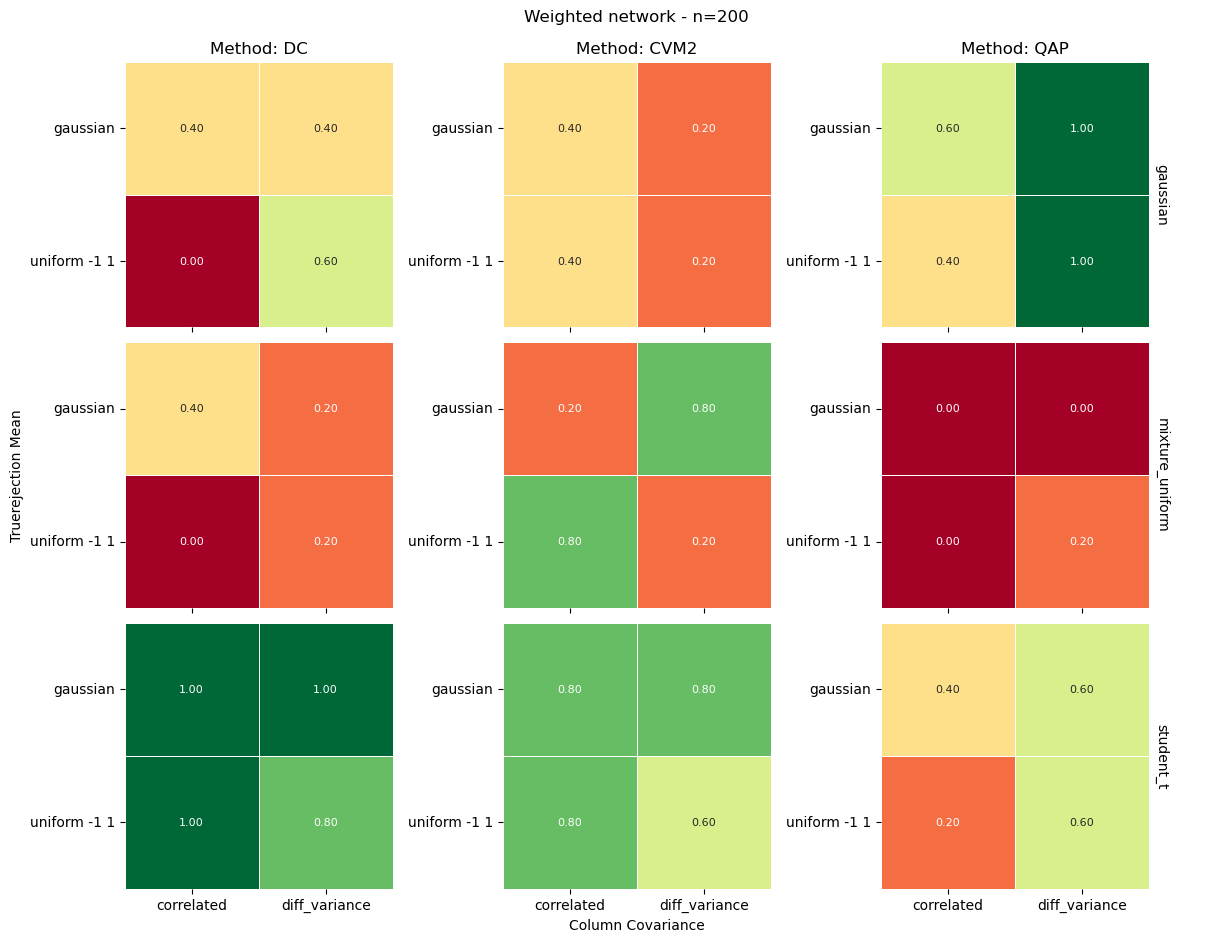

In [ ]:
temp = agg_02_gaussian.copy()
temp['method'].replace({
    'DiffusionCorrelation':'DC', 
    'ObservedCVMPermutationTest_1':'CVM1',
    'ObservedCVMPermutationTest_2':'CVM2',
    }, inplace=True)

#temp = temp[temp['method']!='CVM1']

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_heatmap,
    x_axis="column_covariance",
    y_axis="TrueRejection_mean",
    factors=["marginals", "method", "copula"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - n=200",
    name_conversion={'n':'n (Number of nodes)', 'marginals':''},
    show_row_names=False
)

/var/folders/gg/0gs3g0gx6w57ybpx_mss5wdh0000gq/T/ipykernel_74888/1674274616.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp['method'].replace({


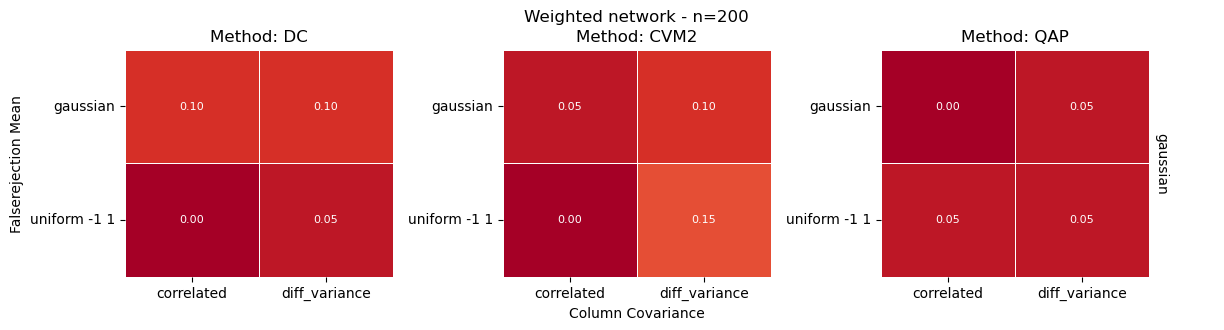

In [ ]:
temp = agg_null_bernoulli.copy()
temp['method'].replace({
    'DiffusionCorrelation':'DC', 
    'ObservedCVMPermutationTest_1':'CVM1',
    'ObservedCVMPermutationTest_2':'CVM2',
    }, inplace=True)

#temp = temp[temp['method']!='CVM1']

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_heatmap,
    x_axis="column_covariance",
    y_axis="FalseRejection_mean",
    factors=["marginals", "method", "copula"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - n=200",
    name_conversion={'n':'n (Number of nodes)', 'marginals':''},
    show_row_names=False
)

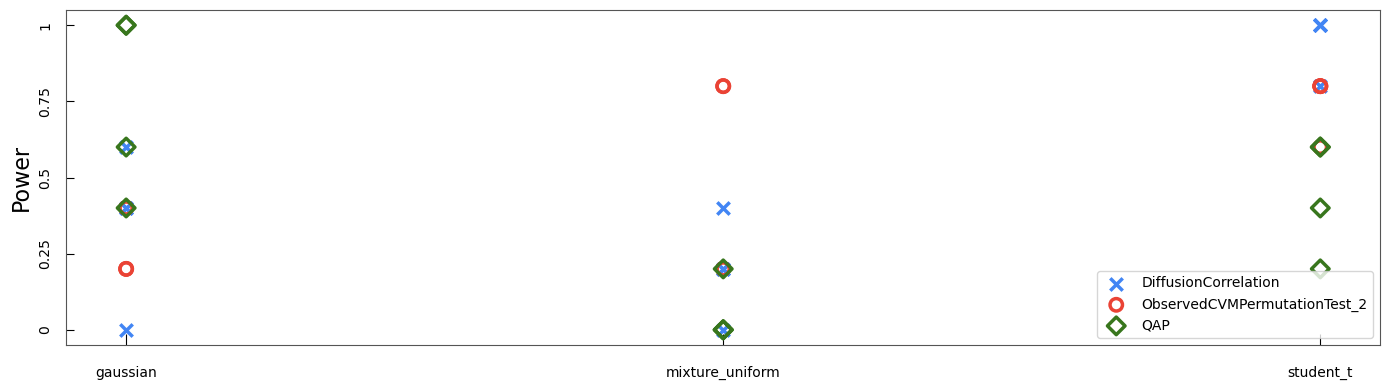

In [ ]:
color_map = {
    'DiffusionCorrelation': '#4285F4', # Blue
    'ObservedCVMPermutationTest_2': '#EA4335', # Red
    'QAP': '#38761D',  # Dark Green
    'RVPermutationTest_latent': '#FBBC05'  # Yellow
}

marker_map = {
    'DiffusionCorrelation': 'x',
    'ObservedCVMPermutationTest_2': 'o',
    'QAP': 'D',
    'RVPermutationTest_latent': 'v'
}

df = agg_02_gaussian[(agg_02_gaussian['n'] == 150) & (agg_02_gaussian['method'].isin(marker_map.keys()))].copy()
# 3. Create the plot
# The image has a wide aspect ratio, so we use 14x4
fig, ax = plt.subplots(figsize=(14, 4))

# Group by method to plot each set of points with its specific style
for method in df['method'].unique():
    subset = df[df['method'] == method]
    
    marker = marker_map[method]
    color = color_map[method]
    
    # 'x' markers are just lines, so they don't take face/edge colors the same way
    if marker == 'x':
        ax.scatter(subset['copula'], subset['TrueRejection_mean'], 
                   marker=marker, color=color, 
                   s=80, linewidths=2.5, label=method, zorder=3)
    else:
        # For circles, diamonds, triangles: make them hollow with thick edges
        ax.scatter(subset['copula'], subset['TrueRejection_mean'], 
                   marker=marker, edgecolors=color, facecolors='none', 
                   s=80, linewidths=2.5, label=method, zorder=3)

# 4. Format the axes to match the image
ax.set_ylabel('Power', fontsize=16)
ax.set_ylim(-0.05, 1.05) # Add a tiny bit of padding so markers don't get cut off
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1'], rotation=90, va='center')

# Remove the x-axis label entirely (as in the image)
ax.set_xlabel('')

# Tweak the ticks to match the inward/outward styling in the image
ax.tick_params(axis='y', direction='in', length=6, pad=10)
ax.tick_params(axis='x', direction='in', length=8, pad=15)

# Add a subtle grey border around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('#555555')

# Optional: Add a legend (the original image doesn't have one, but it's usually helpful)
# plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/gg/0gs3g0gx6w57ybpx_mss5wdh0000gq/T/ipykernel_74888/359501063.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


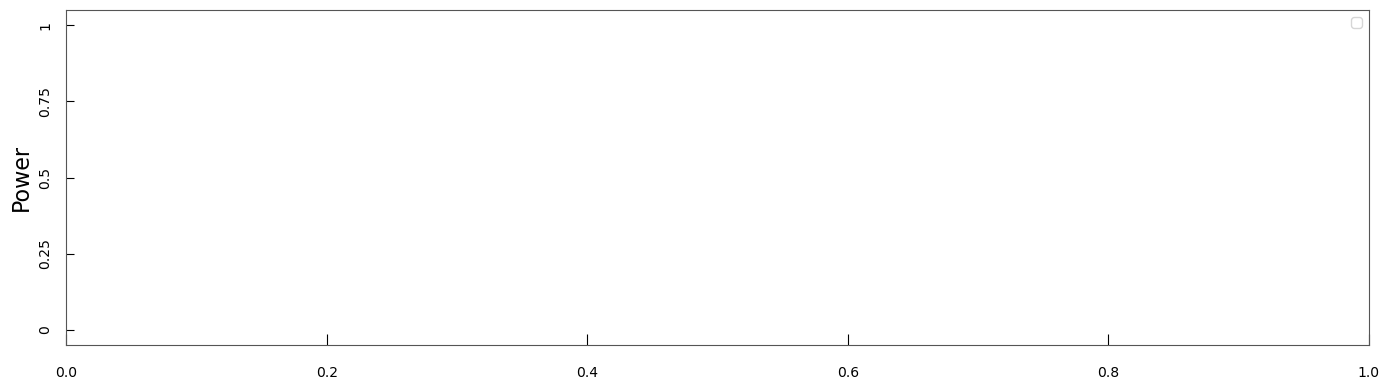

In [ ]:
df = agg_02_bernoulli[(agg_02_bernoulli['n'] == 75) & (agg_02_bernoulli['method'].isin(marker_map.keys()))].copy()
# 3. Create the plot
# The image has a wide aspect ratio, so we use 14x4
fig, ax = plt.subplots(figsize=(14, 4))

# Group by method to plot each set of points with its specific style
for method in df['method'].unique():
    subset = df[df['method'] == method]
    
    marker = marker_map[method]
    color = color_map[method]
    
    # 'x' markers are just lines, so they don't take face/edge colors the same way
    if marker == 'x':
        ax.scatter(subset['latent_sim'], subset['TrueRejection_mean'], 
                   marker=marker, color=color, 
                   s=80, linewidths=2.5, label=method, zorder=3)
    else:
        # For circles, diamonds, triangles: make them hollow with thick edges
        ax.scatter(subset['latent_sim'], subset['TrueRejection_mean'], 
                   marker=marker, edgecolors=color, facecolors='none', 
                   s=80, linewidths=2.5, label=method, zorder=3)

# 4. Format the axes to match the image
ax.set_ylabel('Power', fontsize=16)
ax.set_ylim(-0.05, 1.05) # Add a tiny bit of padding so markers don't get cut off
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1'], rotation=90, va='center')

# Remove the x-axis label entirely (as in the image)
ax.set_xlabel('')

# Tweak the ticks to match the inward/outward styling in the image
ax.tick_params(axis='y', direction='in', length=6, pad=10)
ax.tick_params(axis='x', direction='in', length=8, pad=15)

# Add a subtle grey border around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('#555555')

# Optional: Add a legend (the original image doesn't have one, but it's usually helpful)
# plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
1/0

ZeroDivisionError: division by zero

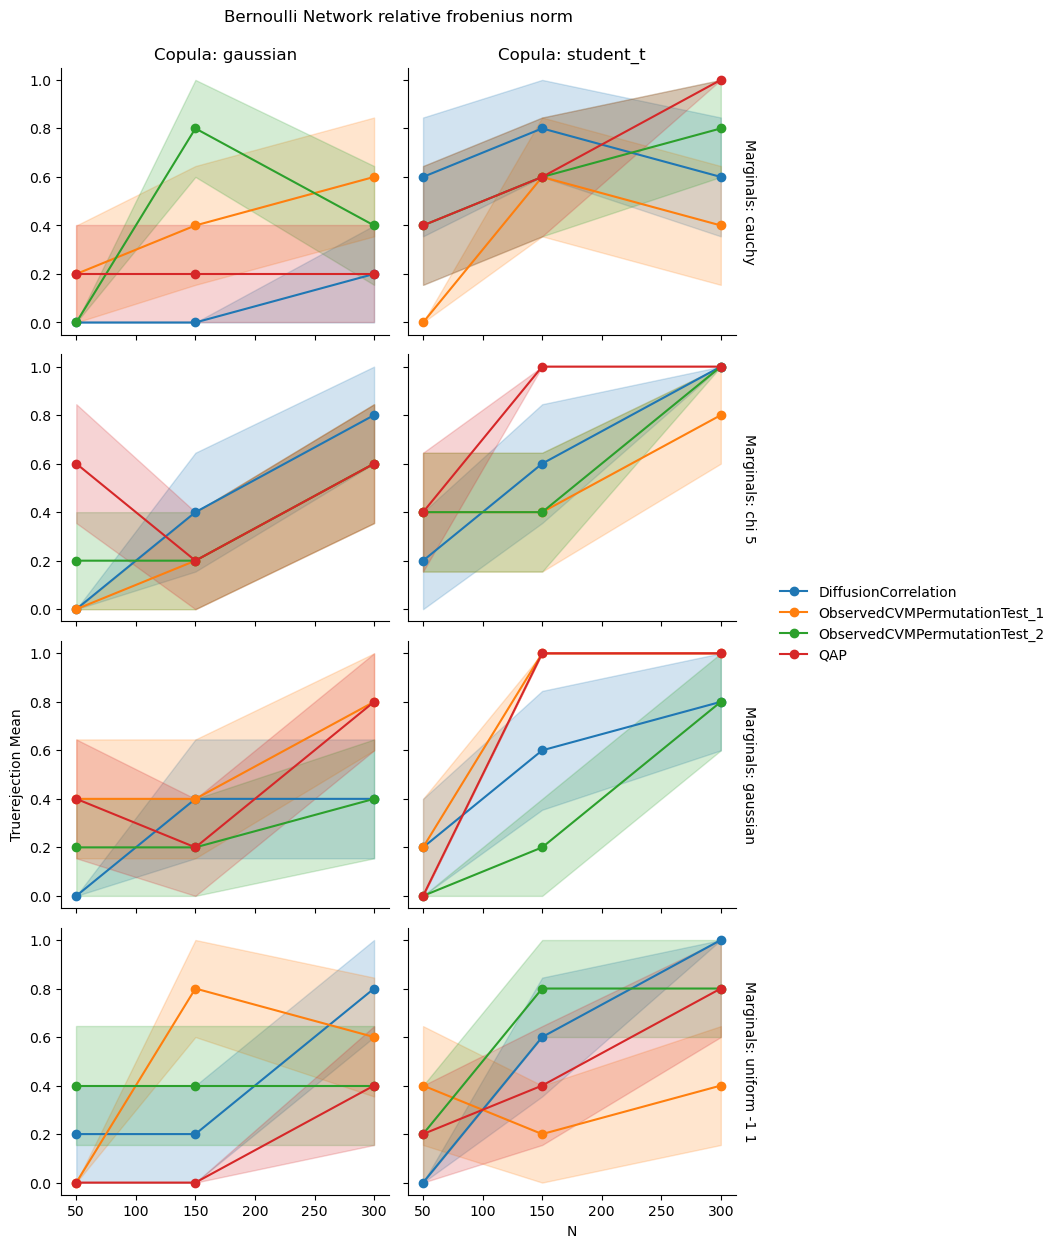

In [ ]:
plot_grid(
    grouped_stats=agg_02_gaussian_correlated,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network relative frobenius norm",
)

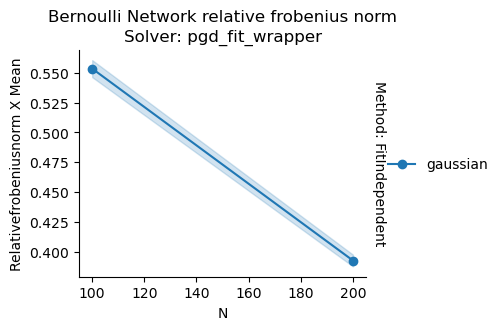

In [ ]:
plot_grid(
    grouped_stats=agg_02_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["marginals", "solver", "method"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network relative frobenius norm",
)

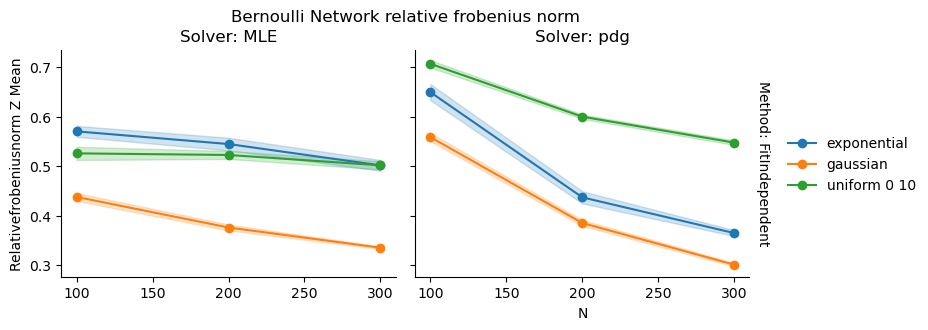

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_bernoulli_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_z_mean",
    factors=["marginals", "solver", "method"],
    height=3,
    se_bands="RelativeFrobeniusNorm_z_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network relative frobenius norm",
)

In [ ]:
plot_grid(
    grouped_stats=agg_gaussian_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="Gaussian Network false rejection rate",
)

plot_grid(
    grouped_stats=agg_bernoulli_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="Bernoulli Network false rejection rate",
)

KeyError: 'solver'

: 

: 

### Logistic rdpg solver

In [ ]:
nsim = 100
n = 100
k = 2
rho = 0
false_rej = 0
for i in range(nsim):
    rng = np.random.default_rng()

    md = GaussianNetwork(n=n, k=k, rho=rho, rng=rng, edge_var=1)

    A, B, X, Z = md.generate()

    method = RVPermutationTest(rng=rng, shrink=0, solver=MLE_gaussian, rho=rho)

    method.fit(A, B=B, X=X, Z=Z, rv_coefficient_function=rv_coefficient_adjusted)

    estimated = method.get_estimated()
    truth = method.get_truth()

    false_rej += FalseRejection()(estimated, truth)

print(false_rej / nsim)

0.03


: 

: 

### Testing Logistic RDPG

In [ ]:
nsim = 200
n = [10, 25, 50, 100, 200, 300]
k = [2, 5]
rho = [0, 0.1]
alpha = [0.05]
marginal_z = [stats.norm]
marginal_x = [stats.norm]
marginal_x_params = [{"a": 2, "b": 5}]
marginal_z_params = [{"a": 2, "b": 5}]
solver = [MLE_gaussian]
edge_var = [1, 3, 5]
dgp = [GaussianNetwork]
methods = [RVPermutationTest]
metrics = [FalseRejection(), TrueRejection(), Rejection()]
rv_coefficient_function = [rv_coefficient_adjusted, rv_coefficient]

rng = np.random.default_rng(1)

param_names = [
    "dgp",
    "method",
    "n",
    "k",
    "rho",
    "alpha",
    "marginal_z",
    "marginal_x",
    "edge_var",
    "solver",
    "rv_coefficient_function",
]

param_values = product(
    dgp,
    methods,
    n,
    k,
    rho,
    alpha,
    marginal_z,
    marginal_x,
    edge_var,
    solver,
    rv_coefficient_function,
)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(
    nsim=nsim,
    metrics=metrics,
    factorial_design=factorial_design,
    rng=rng,
    parallel=True,
)

Running scenarios: 100%|██████████| 28800/28800 [00:57<00:00, 498.96it/s]


: 

: 

In [ ]:
out = pd.DataFrame(out)
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x["edge_var"])

out["dgp"] = out["args"].apply(lambda x: str(x["dgp"].__name__))

out["solver"] = out["args"].apply(lambda x: str(x["solver"].__name__))
out["rho"] = out["args"].apply(lambda x: x["rho"])
out["method"] = out["args"].apply(lambda x: str(x["method"].__name__))
out["rv_coefficient_function"] = out["args"].apply(
    lambda x: str(x["rv_coefficient_function"].__name__)
)

: 

: 

In [ ]:
out_null = out[out["rho"] == 0]
out_alt = out[out["rho"] != 0]

: 

: 

In [ ]:
agg_out_null = aggregate_results(
    out_null,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "rv_coefficient_function"],
)
agg_out_alt = aggregate_results(
    out_alt,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "rv_coefficient_function"],
)

: 

: 

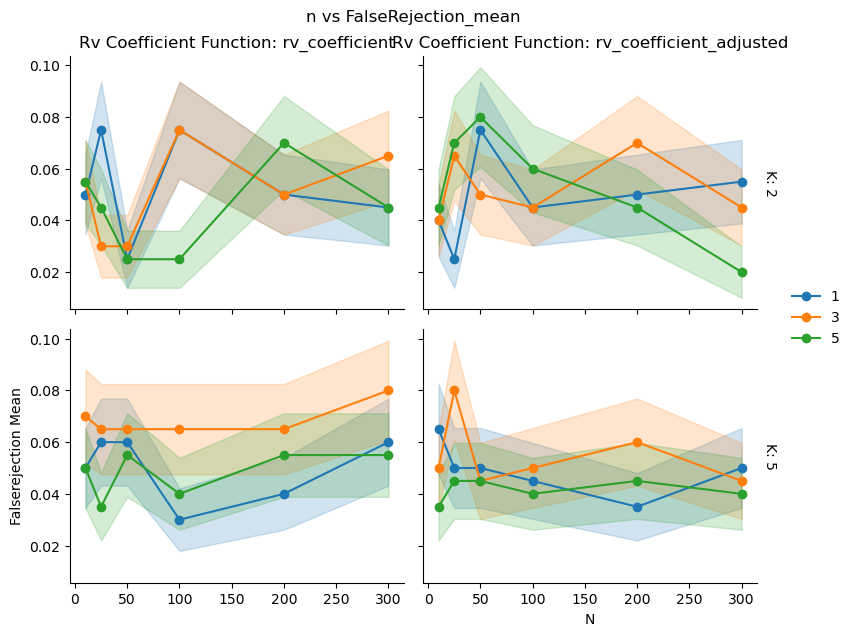

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_out_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["edge_var", "rv_coefficient_function", "k"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
)

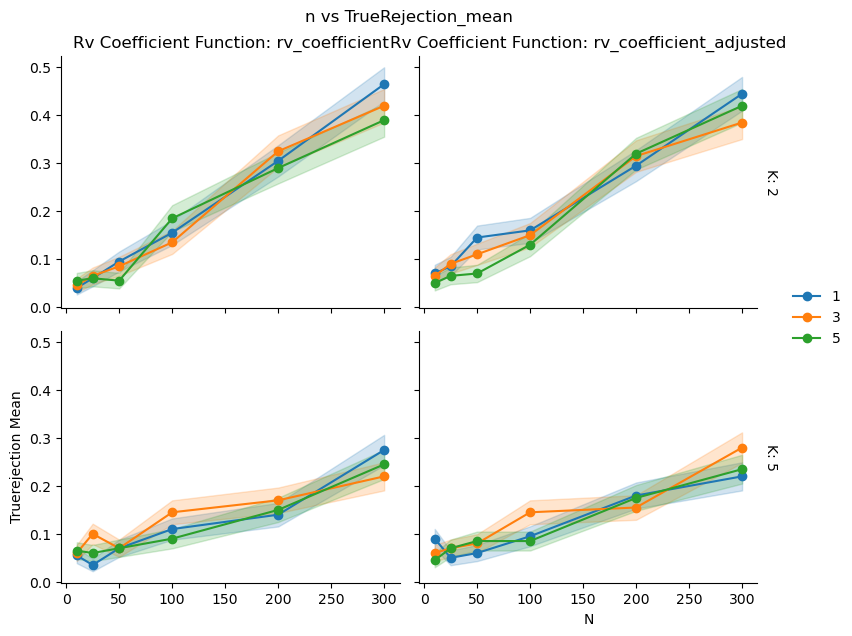

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_out_alt,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["edge_var", "rv_coefficient_function", "k"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
)

In [ ]:
1 / 0

ZeroDivisionError: division by zero

: 

: 

## NORM results

In [ ]:
out = pd.DataFrame(out)
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x["edge_var"])

out["dgp"] = out["args"].apply(lambda x: str(x["dgp"].__name__))

out["RelativeFrobeniusNorm_z"] = out["RelativeFrobeniusNorm"].apply(lambda x: x[1])
out["RelativeFrobeniusNorm_x"] = out["RelativeFrobeniusNorm"].apply(lambda x: x[0])

out["solver"] = out["args"].apply(lambda x: str(x["solver"].__name__))

: 

: 

In [ ]:
out_gaussian = out[out["dgp"] == "GaussianNetwork"]
out_bernoulli = out[out["dgp"] == "BernoulliNetwork"]

out_x_gaussian = out_gaussian.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_z"]
)
out_x_bernoulli = out_bernoulli.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_z"]
)

out_z_gaussian = out_gaussian.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_x"]
)
out_z_bernoulli = out_bernoulli.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_x"]
)

out_x_gaussian_ase = out_x_gaussian[out_x_gaussian["solver"] == "ASE"]
out_x_gaussian_mle = out_x_gaussian[out_x_gaussian["solver"] == "MLE_gaussian"]
out_x_gaussian_mle_logistic = out_x_gaussian[out_x_gaussian["solver"] == "MLE_logistic"]

out_x_bernoulli_ase = out_x_bernoulli[out_x_bernoulli["solver"] == "ASE"]
out_x_bernoulli_mle = out_x_bernoulli[out_x_bernoulli["solver"] == "MLE_gaussian"]
out_x_bernoulli_mle_logistic = out_x_bernoulli[
    out_x_bernoulli["solver"] == "MLE_logistic"
]

: 

: 

In [ ]:
agg_out_z_gaussian = aggregate_results(
    out_z_gaussian,
    y_axis="RelativeFrobeniusNorm_z",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_x_gaussian = aggregate_results(
    out_x_gaussian,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_x_bernoulli = aggregate_results(
    out_x_bernoulli,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_z_bernoulli = aggregate_results(
    out_z_bernoulli,
    y_axis="RelativeFrobeniusNorm_z",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

: 

: 

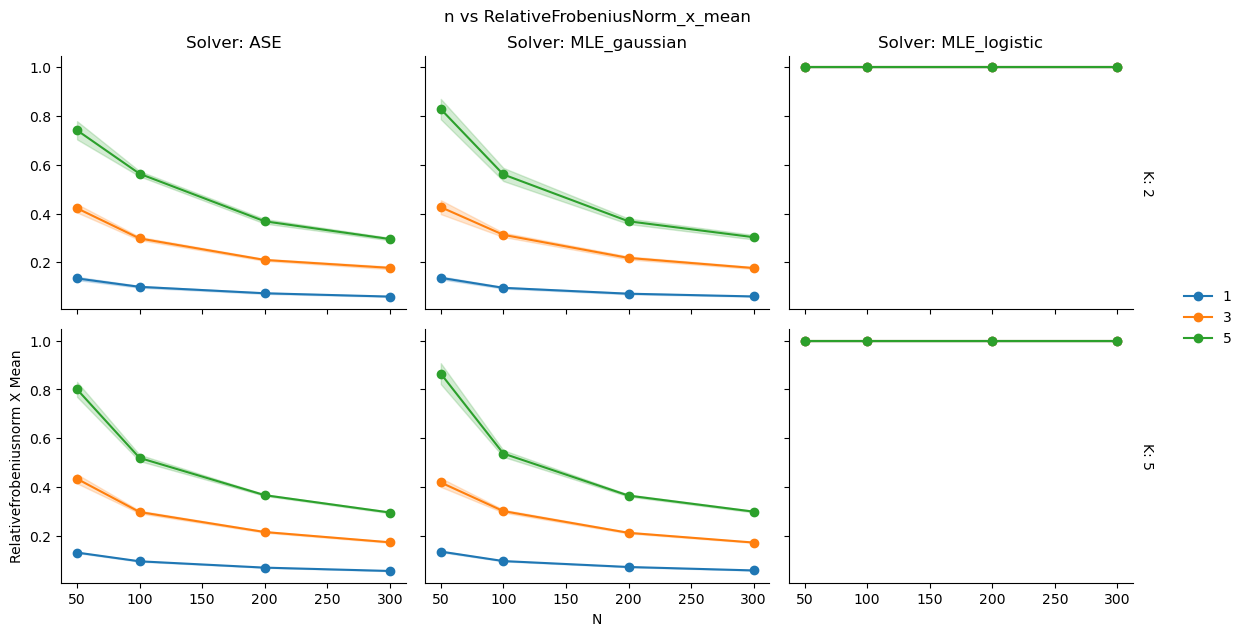

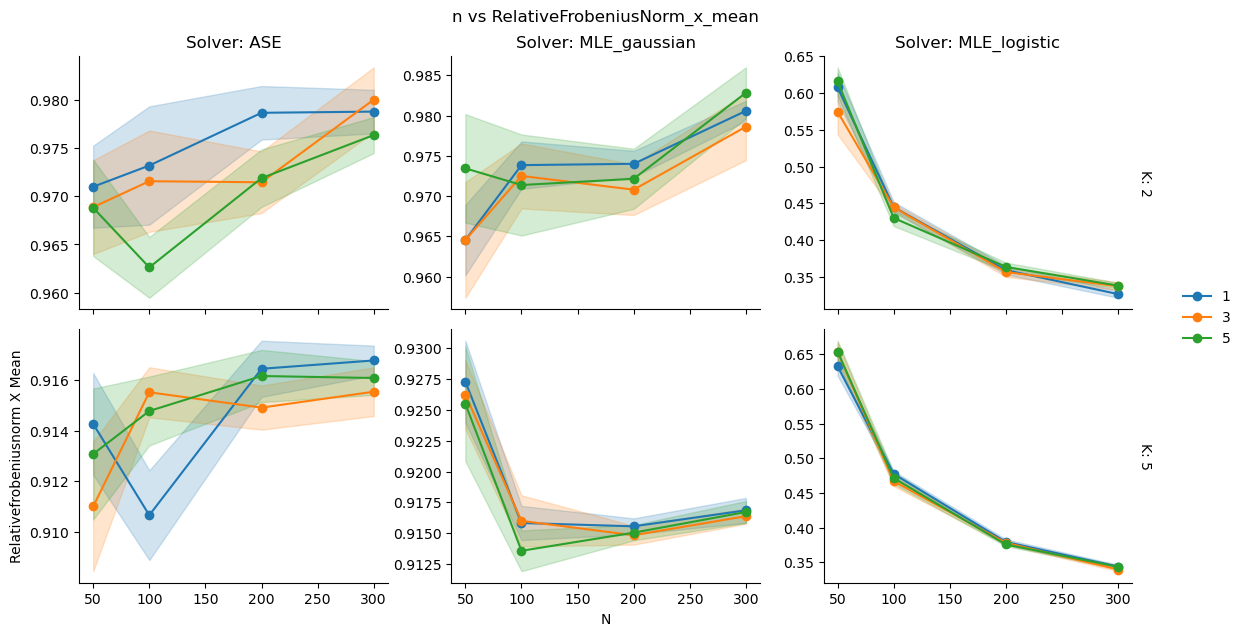

: 

: 

In [ ]:
from src.plot_functions import plot_grid, plot_with_bands

plot_grid(
    grouped_stats=agg_out_x_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["edge_var", "solver", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=True,
)

plot_grid(
    grouped_stats=agg_out_x_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["edge_var", "solver", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
)

In [ ]:
1 / 0


def logistic_grad(params, X, y, mu=None):
    """Utility function for scipy optimizer returning loss and gradient for logistic regression"""
    if mu is None:
        coef = params[:-1]
        mu = params[-1]
    else:
        coef = params

    logits = X @ coef + mu
    loss = np.sum(np.logaddexp(0, logits) - y * logits)
    p = expit(logits)
    error = p - y
    grad_w = X.T @ error
    return loss, grad_w


def solve_logistic_scipy(X, y, mu=None):
    """Solve logistic regression with (possibly) fixed intercept and positive coefficients

    Parameters
    ----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Target vector
    mu : float, optional
        Intercept term, by default None. If None estimate it

    Returns
    -------
    np.ndarray
        Coefficients of the logistic regression
    float
        Intercept term
    """

    n_samples, n_features = X.shape

    if mu is None:
        initial_params = np.zeros(n_features + 1)
        bounds = [(0, None)] * n_features + [(None, None)]
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(
            logistic_grad,
            initial_params,
            args=(X, y),
            method="L-BFGS-B",
            bounds=bounds,
            jac=True,
        )
    else:
        initial_params = np.zeros(n_features)
        bounds = [(0, None)] * n_features
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(
            logistic_grad,
            initial_params,
            args=(X, y, mu),
            method="L-BFGS-B",
            bounds=bounds,
            jac=True,
        )

    return res.x[:n_features], res.x[-1] if mu is None else mu


def MLE_logistic(A, k=2, rng=None, shrink=0, **kwargs):
    # print("WARNING: MLE_logistic is experimental and might not work as expected.")
    """Maximum Likelihood Estimation for Logistic link adjacency matrix

    Parameters
    ----------
    A : np.ndarray
        Adjacency matrix
    k : int, optional
        Number of latent dimensions, by default 2
    rng : np.random.Generator, optional
        Random number generator, by default None
    shrink : int, optional
        Shrinkage parameter, by default 0

    Returns
    -------
    _type_
        _description_
    """
    if rng is None:
        rng = np.random.default_rng()

    # useful quantities
    n = A.shape[0]

    # in the paper it seems to use the frob norm NOT squared, i get better results
    # squaring it
    a_norm_scaled = 1 / (n * (n - 1)) * norm(A, "fro") ** 2

    # mean centered matrix
    A_centered = A - a_norm_scaled

    # from paper, mle of \mu
    mu_hat = -np.log(a_norm_scaled / (1 - a_norm_scaled))

    # use this to fix randomness in eigsh
    v0 = rng.standard_normal(size=A_centered.shape[0])

    evals, evectors = eigsh(A_centered, k=k, which="LM", v0=v0)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evectors = evectors[:, idx]

    # build the matrix of features
    X_big = np.zeros((n * (n - 1) // 2, k))

    for i in range(k):
        t = np.outer(evectors[:, i], evectors[:, i])
        X_big[:, i] = t[np.triu_indices(n, k=1)]

    # define as target the upper diagonal part of A (equal to lower since
    # A symmetric)
    target = A[np.triu_indices(n, k=1)]

    # solve logistic regression with fixed mu and positive constrained coefs
    coefs, mu = solve_logistic_scipy(X_big, target, mu=mu_hat)

    xhat = evectors * np.sqrt(coefs)

    return [xhat], [evals]

ZeroDivisionError: division by zero

: 

: 